# File Structure

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/mobile-price-classification/train.csv
/kaggle/input/mobile-price-classification/test.csv


# Package Import

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,StandardScaler,LabelEncoder
from sklearn.compose import ColumnTransformer,make_column_selector

from sklearn.metrics import classification_report,roc_auc_score,ConfusionMatrixDisplay,f1_score,accuracy_score
from sklearn.exceptions import NotFittedError

import tensorflow as tf
import tensorflow_addons as tfa

sns.set_style('darkgrid')

%matplotlib inline

# Data Import

In [4]:
input_file='/kaggle/input/mobile-price-classification/train.csv'
df=pd.read_csv(input_file)
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
target='price_range'

# EDA (Describe, Info)

In [6]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

# Null Heatmap

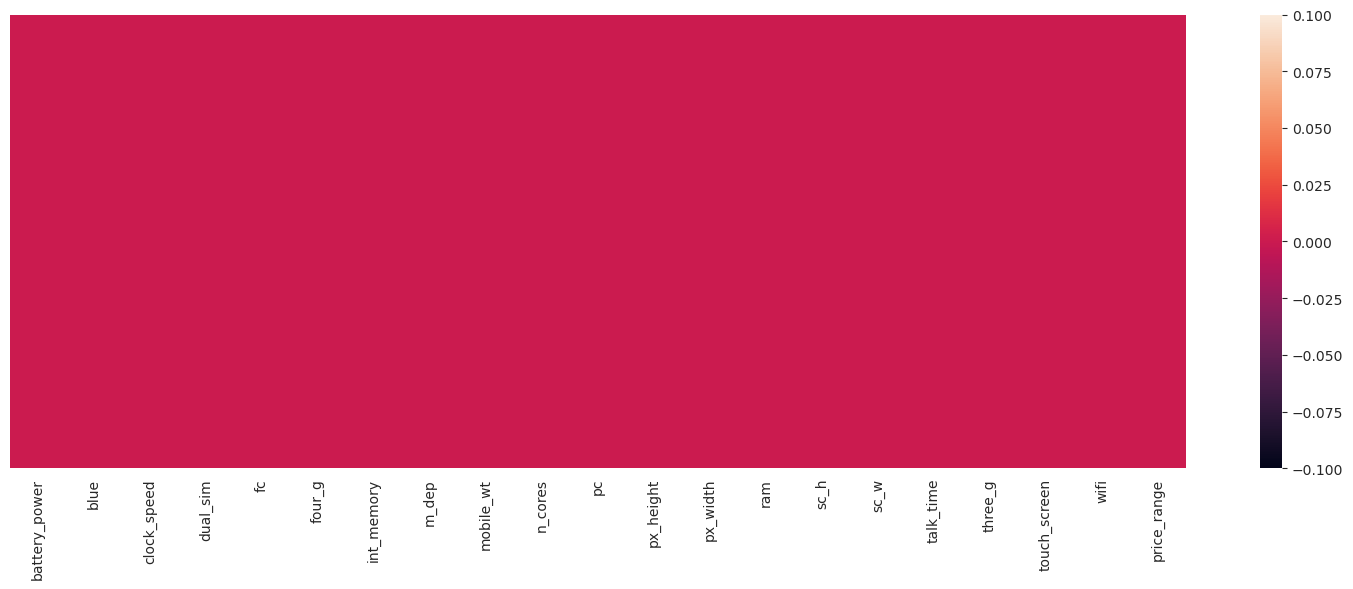

In [8]:
plt.figure(figsize=(15,6))
sns.heatmap(df.isna(),yticklabels=False)
plt.tight_layout()

# EDA Corr

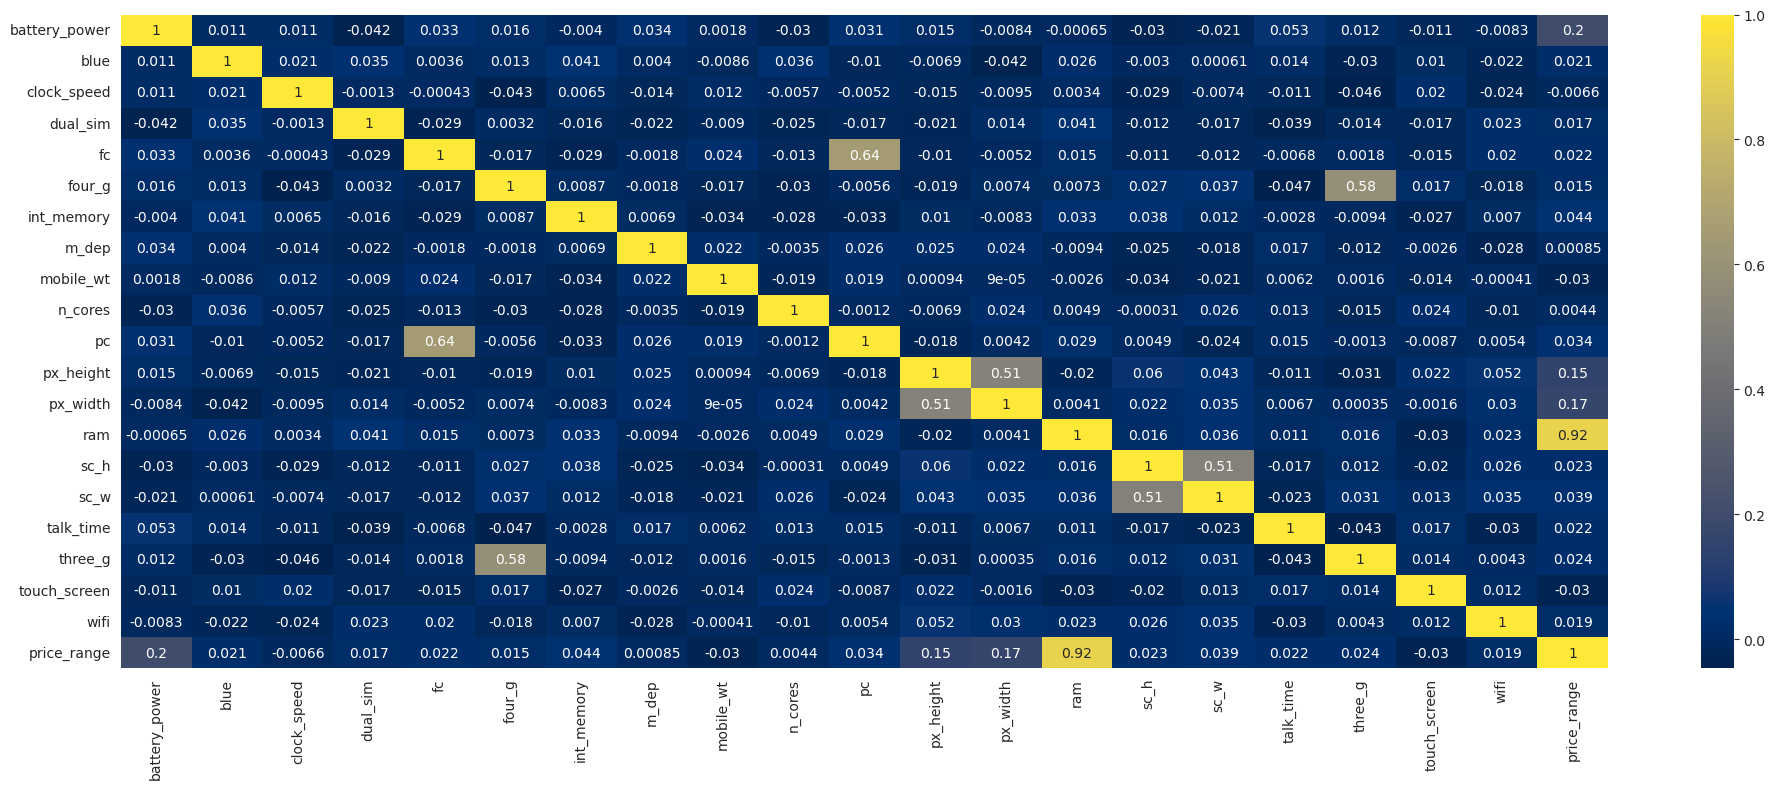

In [9]:
plt.figure(figsize=(20,8))
sns.heatmap(df.corr(),cmap='cividis',annot=True)
plt.tight_layout()

**RAM has high price correlation it seems**

# Feature Transformation

**Bluetooth, dual sim, 4g ,n_cores, 3g ,touch screen , wifi will be int64 and other will be made float64 (except for target)**

In [10]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [11]:
num_cat_col=['blue','dual_sim','four_g','n_cores','three_g','touch_screen','wifi']
print(num_cat_col)

['blue', 'dual_sim', 'four_g', 'n_cores', 'three_g', 'touch_screen', 'wifi']


In [12]:
num_col=[col for col in df.columns if (col not in num_cat_col) and col!=target ]
print(num_col)

['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']


In [13]:
for col in num_col:
    df[col]=df[col].astype('float64')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   float64
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   float64
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   float64
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   float64
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   float64
 11  px_height      2000 non-null   float64
 12  px_width       2000 non-null   float64
 13  ram            2000 non-null   float64
 14  sc_h           2000 non-null   float64
 15  sc_w           2000 non-null   float64
 16  talk_time      2000 non-null   float64
 17  three_g        2000 non-null   int64  
 18  touch_sc

# EDA

In [15]:
# plt.figure(figsize=(10,4))
# sns.countplot(x=target,data=df,palette='deep')
# plt.tight_layout()

In [16]:
# plt.figure(figsize=(30,12))
# j=1
# for i,columns in enumerate(num_cat_col):
#     plt.subplot(2,4,j)
#     sns.countplot(x=columns,data=df,hue=target,palette='deep')
#     j+=1
# plt.tight_layout()

In [17]:
# plt.figure(figsize=(30,20))
# j=1
# for i,columns in enumerate(num_col):
#     plt.subplot(4,4,j)
#     sns.histplot(x=columns,data=df,palette='deep',kde=True)
#     j+=1
# plt.tight_layout()

In [18]:
# plt.figure(figsize=(30,20))
# j=1
# for i,columns in enumerate(num_col):
#     plt.subplot(4,4,j)
#     sns.kdeplot(x=columns,data=df,hue=target,palette='tab10')
#     j+=1
# plt.tight_layout()

# Data Preprocess pipeline

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   float64
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   float64
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   float64
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   float64
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   float64
 11  px_height      2000 non-null   float64
 12  px_width       2000 non-null   float64
 13  ram            2000 non-null   float64
 14  sc_h           2000 non-null   float64
 15  sc_w           2000 non-null   float64
 16  talk_time      2000 non-null   float64
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [20]:
y_oh=OneHotEncoder(handle_unknown='ignore')

In [21]:
oh=OneHotEncoder(drop='first',handle_unknown='ignore')

ms,ss=MinMaxScaler(),StandardScaler()

ct=ColumnTransformer([
    ('num_encoder',ss,make_column_selector(dtype_include='float64'))
],remainder='passthrough',n_jobs=-1)
ct

ColumnTransformer(n_jobs=-1, remainder='passthrough',
                  transformers=[('num_encoder', StandardScaler(),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7a9903808dc0>)])

# Separate X and Y

In [22]:
X=df.drop([target],axis=1)
y=df[[target]]
X.head(1)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842.0,0,2.2,0,1.0,0,7.0,0.6,188.0,2,2.0,20.0,756.0,2549.0,9.0,7.0,19.0,0,0,1


In [23]:
y.head()

,price_range
0,1
1,2
2,2
3,2
4,1


In [24]:
y.value_counts()

price_range
0              500
1              500
2              500
3              500
dtype: int64

# Train Test Split

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,stratify=y,random_state=42)
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=0.1,stratify=y_train,random_state=42)

In [26]:
X_train.shape,y_train.shape

((1620, 20), (1620, 1))

In [27]:
X_test.shape,y_test.shape

((200, 20), (200, 1))

In [28]:
X_test.head(2)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
1552,1562.0,1,0.7,0,0.0,0,55.0,0.1,140.0,8,1.0,1032.0,1776.0,2096.0,15.0,3.0,3.0,0,0,0
1785,1354.0,1,0.7,1,3.0,1,26.0,0.5,136.0,4,6.0,297.0,918.0,2090.0,5.0,1.0,13.0,1,1,0


In [29]:
y_test.head(2)

,price_range
1552,2
1785,1


# Data Preprocess

## **X related processing**

In [30]:
X_train=ct.fit_transform(X_train)
X_val=ct.fit_transform(X_val)
X_test=ct.transform(X_test)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [31]:
print("-"*50)
for i in ct.transformers_:
    print(i)
    if(i[0]!='remainder'):
        print(i[1].get_feature_names_out())   
    print("-"*50)

--------------------------------------------------
('num_encoder', StandardScaler(), ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time'])
['battery_power' 'clock_speed' 'fc' 'int_memory' 'm_dep' 'mobile_wt' 'pc'
 'px_height' 'px_width' 'ram' 'sc_h' 'sc_w' 'talk_time']
--------------------------------------------------
('remainder', 'passthrough', [1, 3, 5, 9, 17, 18, 19])
--------------------------------------------------


## **Y related processing**

In [32]:
y_train.value_counts()

price_range
0              405
1              405
2              405
3              405
dtype: int64

In [33]:
y_oh.fit(y_train)
output_shape=len(y_oh.get_feature_names_out())

y_train_copy = tf.keras.utils.to_categorical(y_train, num_classes=output_shape)
y_val_copy = tf.keras.utils.to_categorical(y_val, num_classes=output_shape)
y_test_copy = tf.keras.utils.to_categorical(y_test, num_classes=output_shape)

In [34]:
X_train.shape,y_train.shape

((1620, 20), (1620, 1))

In [35]:
X_test.shape,y_test.shape

((200, 20), (200, 1))

In [36]:
tup1=None;tup2=None
try:
    tup1=(X_test[0].toarray(),y_test_copy[0]) 
    print("Sparse Matrix to Dense Array")
except:
    tup2=(X_test[0],y_test_copy[0]) 
    print("Normal Matrix to Dense Array")

tup1 if(tup1) else tup2

Normal Matrix to Dense Array


(array([ 0.89781455, -1.03413639, -1.09263196,  1.19291225, -1.34202107,
        -0.01406045, -1.59062433,  1.03043815,  1.26202846, -0.11612559,
         0.55048698, -0.68954188, -1.51967707,  1.        ,  0.        ,
         0.        ,  8.        ,  0.        ,  0.        ,  0.        ]),
 array([0., 0., 1., 0.], dtype=float32))

# Tensorflow Data Batch Setting

In [37]:
batch_size=128

In [38]:
# def convert_sparse_matrix_to_sparse_tensor(X):
#     coo = X.tocoo()
#     indices = np.mat([coo.row, coo.col]).transpose()
#     return tf.sparse.reorder(tf.SparseTensor(indices, coo.data, coo.shape))

# X_train=convert_sparse_matrix_to_sparse_tensor(X_train)
# X_val=convert_sparse_matrix_to_sparse_tensor(X_val)
# X_test=convert_sparse_matrix_to_sparse_tensor(X_test)

In [39]:
data_tf_tr=tf.data.Dataset.from_tensor_slices((X_train, y_train_copy))
data_train_batches = data_tf_tr.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

data_tf_val=tf.data.Dataset.from_tensor_slices((X_val, y_val_copy))
data_val_batches = data_tf_val.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

data_tf_te=tf.data.Dataset.from_tensor_slices((X_test, y_test_copy))
data_test_x_y_batches = data_tf_te.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

In [40]:
#Only for X_test
data_tf_tre=tf.data.Dataset.from_tensor_slices(X_test)
data_test_x_batches = data_tf_tre.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

# Model fitting

## Neural Network Settings

In [41]:
n,m=4,3

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Input,PReLU,LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

l_relu=LeakyReLU()
para_relu = PReLU()
e=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True,verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,patience=3, min_lr=0.001)

In [43]:
y_train.shape

(1620, 1)

In [44]:
model=Sequential()

#Input Layer
model.add(Input(shape=(X_train.shape[1],)))

#Hidden Layer
model.add(Dense((m*n)*X_train.shape[1],activation=para_relu ))
model.add(Dense((m*n)*X_train.shape[1],activation='relu'))
model.add(Dense((m*n)*X_train.shape[1],activation='relu'))
model.add(Dense((m*n)*X_train.shape[1],activation='relu'))
model.add(Dense((m*n)*X_train.shape[1],activation=para_relu))

#Output Layer
model.add(Dense(output_shape,activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics = [ 'accuracy',
                         tf.keras.metrics.AUC(name='AUC_ROC',curve='ROC',num_thresholds=10000) ,
                         tfa.metrics.F1Score(name='F1_Score',num_classes=output_shape,average='macro',threshold=0.5)
                        ]
             )

In [45]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 240)               5280      
                                                                 
 dense_1 (Dense)             (None, 240)               57840     
                                                                 
 dense_2 (Dense)             (None, 240)               57840     
                                                                 
 dense_3 (Dense)             (None, 240)               57840     
                                                                 
 dense_4 (Dense)             (None, 240)               58080     
                                                                 
 dense_5 (Dense)             (None, 4)                 964       
                                                                 
Total params: 237,604
Trainable params: 237,604
Non-trai

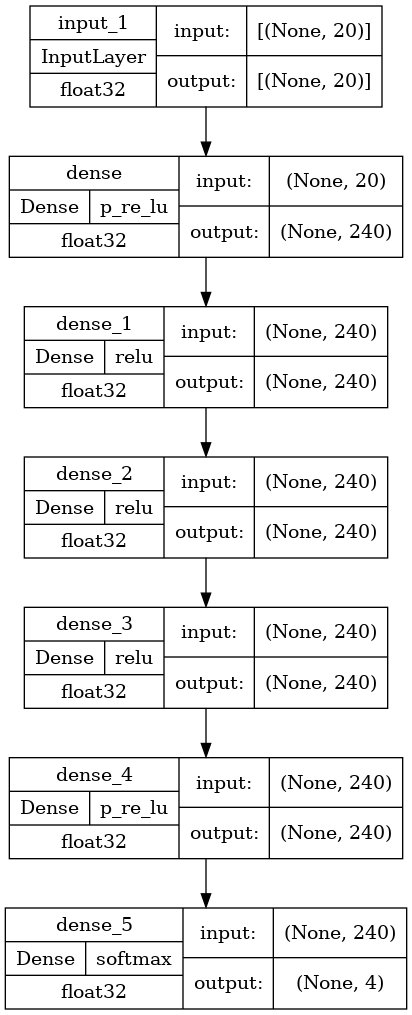

In [46]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model.png',show_shapes=True,show_dtype=True,show_layer_activations=True)

In [47]:
%%time
history=model.fit(data_train_batches,epochs=200,callbacks=[e,reduce_lr],
                  validation_data=data_val_batches,verbose=1)

Epoch 1/200
13/13 [==============================] - 6s 36ms/step - loss: 1.0961 - accuracy: 0.5154 - AUC_ROC: 0.8137 - F1_Score: 0.2413 - val_loss: 0.6144 - val_accuracy: 0.7722 - val_AUC_ROC: 0.9452 - val_F1_Score: 0.5747 - lr: 0.0010
Epoch 2/200
13/13 [==============================] - 0s 7ms/step - loss: 0.4386 - accuracy: 0.8198 - AUC_ROC: 0.9667 - F1_Score: 0.7898 - val_loss: 0.3072 - val_accuracy: 0.8889 - val_AUC_ROC: 0.9823 - val_F1_Score: 0.8893 - lr: 0.0010
Epoch 3/200
13/13 [==============================] - 0s 8ms/step - loss: 0.2501 - accuracy: 0.8994 - AUC_ROC: 0.9883 - F1_Score: 0.8985 - val_loss: 0.2230 - val_accuracy: 0.9167 - val_AUC_ROC: 0.9907 - val_F1_Score: 0.9157 - lr: 0.0010
Epoch 4/200
13/13 [==============================] - 0s 9ms/step - loss: 0.1569 - accuracy: 0.9420 - AUC_ROC: 0.9958 - F1_Score: 0.9419 - val_loss: 0.1962 - val_accuracy: 0.9278 - val_AUC_ROC: 0.9920 - val_F1_Score: 0.9227 - lr: 0.0010
Epoch 5/200
13/13 [==============================] - 0s

# Testing

In [48]:
model.evaluate(data_test_x_y_batches)

2/2 [==============================] - 0s 13ms/step - loss: 0.1536 - accuracy: 0.9400 - AUC_ROC: 0.9952 - F1_Score: 0.9395


[0.15358643233776093, 0.9399999976158142, 0.995208203792572, 0.939456045627594]

In [49]:
score_dict={};j=0

In [50]:
def tester_func(model_list,X_test,y_test):
    for i,clf in enumerate(model_list):
       
        pred_proba=None;pred=None
        clf_name = clf.__class__.__name__

        try:
            pred_proba=clf.predict(X_test)
            pred=np.argmax(clf.predict(X_test), axis=-1)
        except NotFittedError as e:
            raise(e)

        print("-"*80)
        print(f"Predicting {clf_name} done")

        score_dict[clf_name]={
            'roc_auc_score':roc_auc_score(y_test.values,pred_proba,multi_class='ovr'),
            'f1_score':f1_score(y_test.values,pred,average='macro'),
            'accuracy_score':accuracy_score(y_test.values,pred),
            'model_index':int(i)
        }
        j=i
    
    print("-"*80)
    return j

In [51]:
indexer=tester_func([model],X_test,y_test)

7/7 [==============================] - 0s 2ms/step
--------------------------------------------------------------------------------
Predicting Sequential done
--------------------------------------------------------------------------------


In [52]:
indexer

0

In [53]:
score_pd=pd.DataFrame(score_dict).transpose().sort_values('f1_score',ascending=False)
score_pd

,accuracy_score,f1_score,model_index,roc_auc_score
Sequential,0.94,0.939456,0.0,0.995733


# Confusion matrix for Top model

In [54]:
print(classification_report( y_test.values , np.argmax(model.predict(X_test), axis=-1) ))

7/7 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        50
           1       0.91      0.98      0.94        50
           2       0.95      0.84      0.89        50
           3       0.91      0.98      0.94        50

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



7/7 [==============================] - 0s 2ms/step


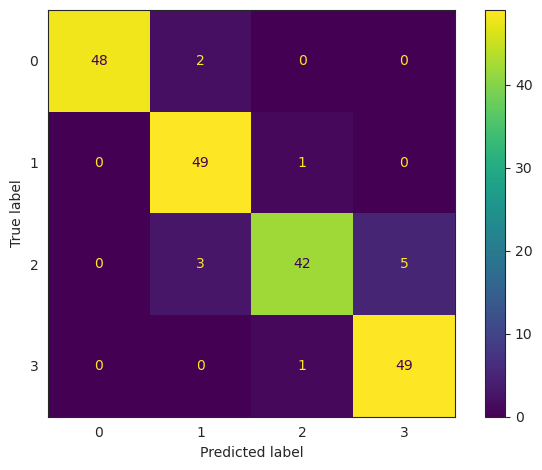

In [55]:
sns.set_style('white')
ConfusionMatrixDisplay.from_predictions( y_test.values , np.argmax(model.predict(X_test), axis=-1) )
plt.tight_layout()

# Testing (test.csv)

In [56]:
# test_df=pd.read_csv('/kaggle/input/mobile-price-classification/test.csv')
# test_df.head()

# test_df.drop(['id'],axis=1,inplace=True)

# test_df.info()

# for col in num_col:
#     test_df[col]=test_df[col].astype('float64')

# test_df.info()

# X_test_df=test_df.copy()

# X_test_df=ct.transform(X_test_df)

# pred=clf_list[win_index].predict_proba(X_test_df)

# pred